<a href="https://colab.research.google.com/github/suryasurya00877-glitch/Student---performance---analysis-/blob/main/Student_perfomance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- முதல் 5 மாணவர்கள் ---
   Student_ID  Study_Hours  Attendance_Perc  Past_Exam_Score  Final_Score
0         101            2               65               50           52
1         102            3               70               55           58
2         103            5               80               68           72
3         104            7               88               80           85
4         105            1               60               45           48

--- புள்ளிவிவரம் ---
       Student_ID  Study_Hours  Attendance_Perc  Past_Exam_Score  Final_Score
count    10.00000     10.00000        10.000000        10.000000     10.00000
mean    105.50000      4.80000        78.800000        68.100000     71.40000
std       3.02765      2.65832        12.638565        17.045364     17.40498
min     101.00000      1.00000        60.000000        45.000000     48.00000
25%     103.25000      3.00000        70.500000        55.750000     58.50000
50%     105.50000      4.50000        77

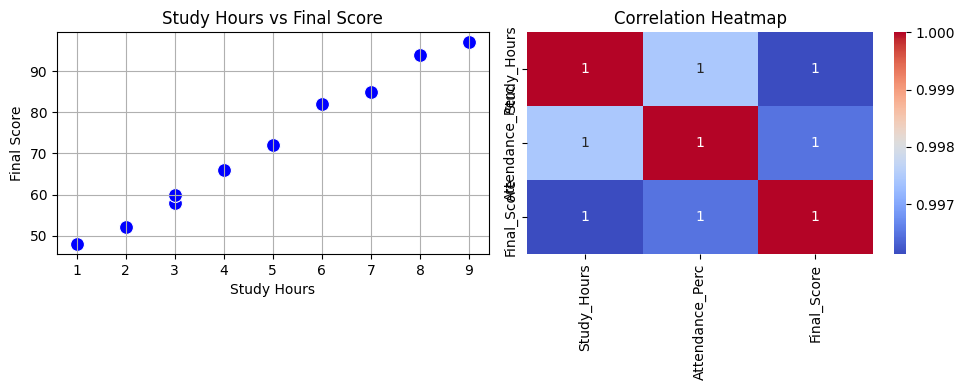


Model Accuracy (R2 Score): 98.37%
கணிக்கப்பட்ட புதிய மதிப்பெண்: 78.92


In [1]:
# 1. Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 2. Dataset
data = {
    'Student_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Study_Hours': [2, 3, 5, 7, 1, 8, 4, 6, 9, 3],
    'Attendance_Perc': [65, 70, 80, 88, 60, 95, 75, 85, 98, 72],
    'Past_Exam_Score': [50, 55, 68, 80, 45, 90, 62, 78, 95, 58],
    'Final_Score': [52, 58, 72, 85, 48, 94, 66, 82, 97, 60],
}

df = pd.DataFrame(data)

print('--- முதல் 5 மாணவர்கள் ---')
print(df.head())

print('\n--- புள்ளிவிவரம் ---')
print(df.describe())

# 3. Data Visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Study_Hours', y='Final_Score', data=df, color='blue', s=100)
plt.title('Study Hours vs Final Score')
plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.heatmap(
    df[['Study_Hours', 'Attendance_Perc', 'Final_Score']].corr(),
    annot=True,
    cmap='coolwarm',
)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# 4. Machine Learning Model
X = df[['Study_Hours', 'Attendance_Perc', 'Past_Exam_Score']]
y = df['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f'\nModel Accuracy (R2 Score): {accuracy * 100:.2f}%')

# 5. Prediction
new_student = pd.DataFrame(
    [[6, 85, 75]],
    columns=['Study_Hours', 'Attendance_Perc', 'Past_Exam_Score'],
)
predicted_score = model.predict(new_student)
print(f'கணிக்கப்பட்ட புதிய மதிப்பெண்: {predicted_score[0]:.2f}')